In [3]:
import sys, os

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import binom

from pathlib import Path
sys.path.append(str(Path.cwd().parents[2]))


from im_net import datamanager, plotting

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
plot_path = "../figures/appendix/pid_atoms_bins"

plt.rcParams['figure.figsize'] = (2.2, 1.5)
plt.rcParams['figure.dpi'] = 300
plt.rcParams.update({'font.size': 8})
plt.rcParams['svg.fonttype'] = 'none'

## Data Loading

PID atoms as a function of memory load $\alpha$, computed for several discretisation
bin counts. Analytical results for $N = 100$ (Hebbian network, SX measure) are
overlaid for comparison.

**Training command:**
```bash
python src/training.py storage=basic params.pref_gpu=False params.seed='range(5)' params.alpha='range(0.05,2.05,0.05)' storage.final.pid=True params.n_bins=2,4,8,16,32,64
```

In [3]:
def Isx_from_grids(all_r, P_tp, P_tm):
    """I^sx = Σ_r P(r|t=+1) log2[ 2(P(r|t=-1) + P(sgn(r)|t=+1)) / (P(r|t=-1) + 1) ]"""
    p_e   = P_tp[all_r < 0].sum()
    P_sgn = np.where(all_r >= 0, 1 - p_e, p_e)
    numer = 2.0 * (P_tm + P_sgn)
    denom = P_tm + 1.0
    ok    = P_tp > 1e-300
    return float(np.dot(P_tp[ok], np.log2(numer[ok] / denom[ok])))


def analytic_pid(N, m_pat):
    """Exact PID atoms for a Hebbian Hopfield network (SX measure)."""
    L     = (N - 1) * (m_pat - 1)
    k     = np.arange(L + 1)
    probs = binom.pmf(k, L, 0.5)
    r_p   = (N - 1) + 2 * k - L
    r_m   = -(N - 1) + 2 * k - L
    all_r = np.union1d(r_p, r_m)

    def _map(rv, pv):
        out = np.zeros(len(all_r))
        out[np.searchsorted(all_r, rv)] = pv
        return out

    P_tp  = _map(r_p, probs)
    P_tm  = _map(r_m, probs)
    red   = Isx_from_grids(all_r, P_tp, P_tm)
    p_e   = P_tp[all_r < 0].sum()

    if 0 < p_e < 1:
        I_YT = 1.0 + p_e * np.log2(p_e) + (1 - p_e) * np.log2(1 - p_e)
    else:
        I_YT = 1.0

    return I_YT - red, 1.0 - red, red, red - I_YT, 0.0  # uniq_T, uniq_R, red, syn, res

In [ ]:
# TODO: set path to PID atoms vs bin-count experiment folder
path = ''

dm = datamanager.DataManager(path, mode='analysis', add_run_properties=True, verbose=0)
dm.all = dm.all[dm.all['finished'] == True]
dm.sel = dm.sel.sort_values(by=['params.n_bins', 'params.alpha', 'params.seed'])

n_bins_arr = np.unique(dm.sel['params.n_bins'].to_numpy())
alpha_arr  = np.unique(dm.sel['params.alpha'].to_numpy())
pid_raw    = dm.load_selected('pid_atoms')

# Aggregate: shape (n_bins, n_alpha, n_seeds_per_group, 5)
n_groups   = len(n_bins_arr) * len(alpha_arr)
seeds_per  = len(pid_raw) // (n_groups * 5)
pid_avg    = np.zeros((len(pid_raw) // 5, 5))
for i in range(len(pid_raw) // 5):
    pid_avg[i] = np.median(np.array(pid_raw[i * 5]['layer1'][0]), axis=1)
pid_avg = pid_avg.reshape((len(n_bins_arr), len(alpha_arr), -1, 5))

# Analytical reference (N=100, SX measure)
N_analytic     = 100
m_analytic     = np.arange(6, int(2 * N_analytic) + 1, 2)
alpha_analytic = m_analytic / N_analytic
atoms_analytic = np.array([analytic_pid(N_analytic, m) for m in m_analytic])

print(f"n_bins: {n_bins_arr}")
print(f"alpha values: {len(alpha_arr)}, pid_avg shape: {pid_avg.shape}")

n_bins: [ 2  4  8 16 32 64]
alpha values: 20, pid_avg shape: (6, 20, 1, 5)


## Figure: PID Atoms vs. Bin Count

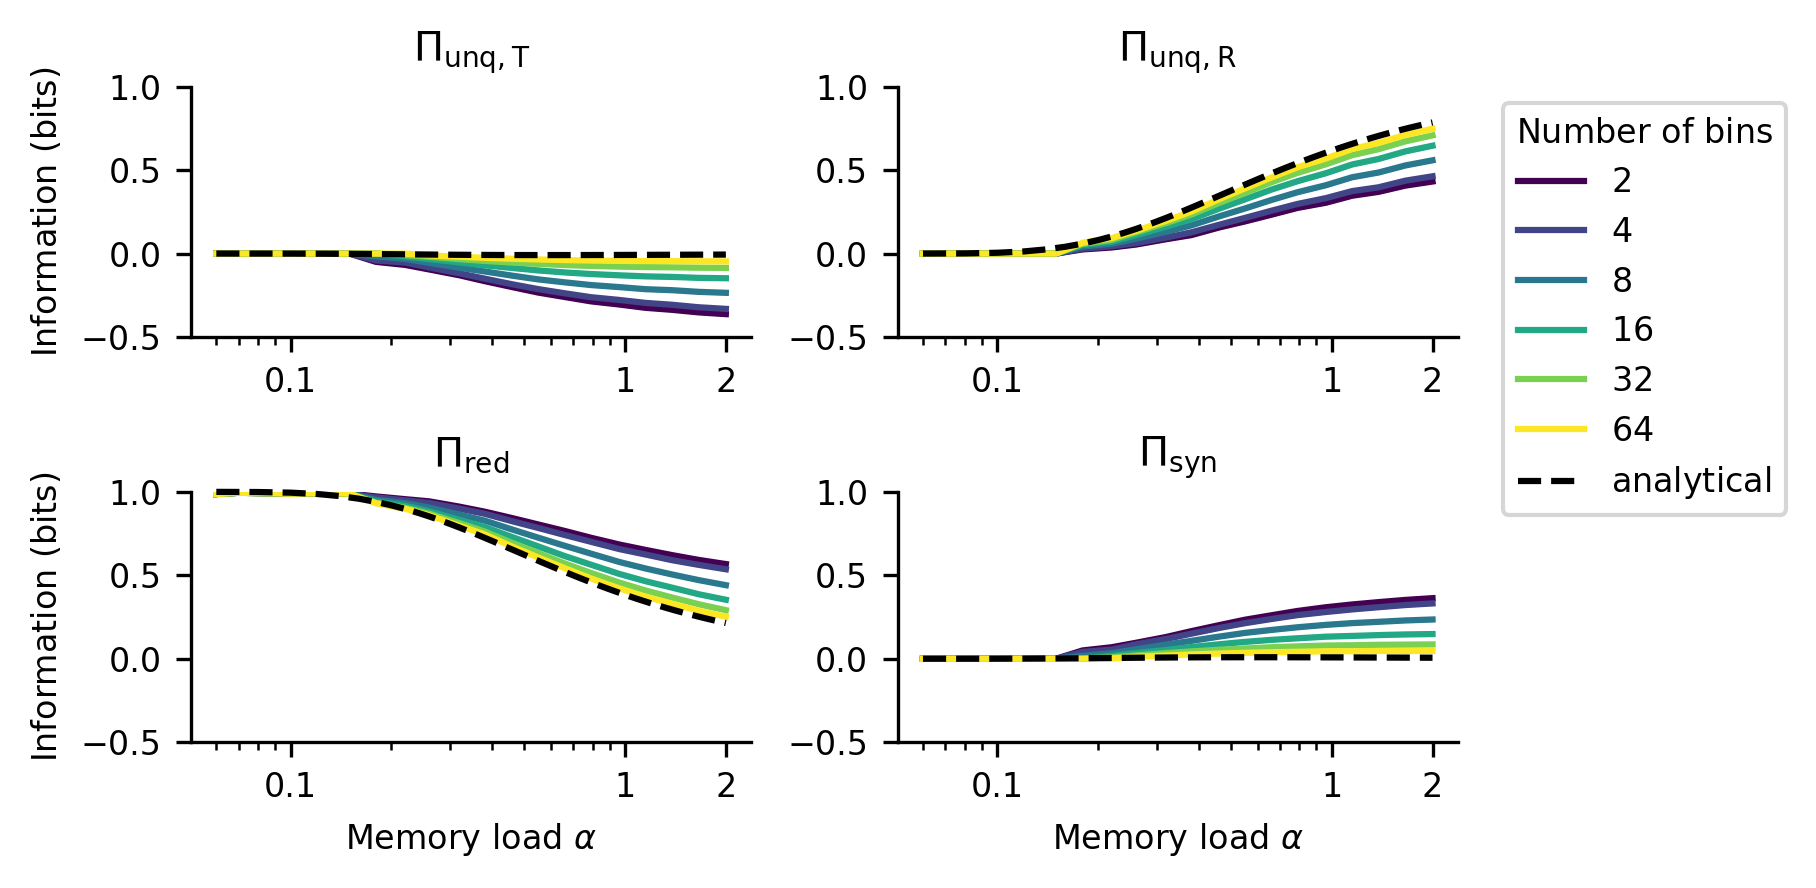

In [5]:
titles = [r'$\Pi_{\mathrm{unq,T}}$', r'$\Pi_{\mathrm{unq,R}}$',
          r'$\Pi_{\mathrm{red}}$',   r'$\Pi_{\mathrm{syn}}$']
colors = plt.cm.viridis(np.linspace(0, 1, len(n_bins_arr)))
s      = 0  # alpha index to start from

fig, ax = plt.subplots(2, 2, figsize=(5, 3), sharex=True, sharey=True)
ax = ax.flatten()

for k in range(4):
    for i, n_bins in enumerate(n_bins_arr):
        ax[k].plot(alpha_arr[s:], pid_avg.mean(axis=2)[i][s:, k],
                   label=f'${int(n_bins)}$', color=colors[i], clip_on=True)
        ax[k].fill_between(alpha_arr[s:],
                           np.percentile(pid_avg, 5,  axis=2)[i][s:, k],
                           np.percentile(pid_avg, 95, axis=2)[i][s:, k],
                           alpha=0.2, color=colors[i])
    # Analytical overlay
    ax[k].plot(alpha_analytic, atoms_analytic[:, k],
               color='black', lw=1.5, ls='--',
               label=r'$\mathrm{analytical}$', zorder=10, clip_on=False)
    ax[k].set_title(titles[k])
    ax[k].set_xscale('log')
    ax[k].set_ylim(-0.5, 1)
    plotting.adjust_spines(ax[k], ['left', 'bottom'], offset_spines=[0, 0])

ax[0].set_ylabel(r'$\mathrm{Information\ (bits)}$')
ax[2].set_ylabel(r'$\mathrm{Information\ (bits)}$')
ax[2].set_xlabel(r'$\mathrm{Memory\ load}\ \alpha$')
ax[3].set_xlabel(r'$\mathrm{Memory\ load}\ \alpha$')
ax[3].set_xticks([0.1, 1, 2])
ax[3].set_xticklabels(['0.1', '1', '2'])

fig.tight_layout()
ax[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left',
             title=r'$\mathrm{Number\ of\ bins}$', ncol=1)
# fig.savefig(f"{plot_path}/pid_atoms_bins.svg", bbox_inches='tight')
plt.show()